# 04 — Computation Graph & Backpropagation

**Repository:** `AI_Engineer-DL` | **Section:** `01_neural_networks_and_dl/logistic_regression`  
**File:** `notebooks/04_computation_graph_and_backprop.ipynb`

> **Prerequisites:** `03_gradient_descent.ipynb` — you need the cost function and the update rule  
> from notebook 03. This notebook explains *why* the gradients take the form they do.
>
> **Core Focus:** You implement the computation graph for logistic regression manually,  
> derive all gradients using the chain rule, and confirm the formulas used in notebook 03.  
> Vectorisation over m examples is deferred to notebook 05.

## 1. What Is This?

When a neural network makes a prediction it runs a sequence of operations — a forward pass.  
A computation graph is just a diagram of those operations, showing what feeds into what.  
Backpropagation is then the process of walking that graph backwards, using the chain rule  
at each node to compute how much each parameter contributed to the final loss.  
Every deep learning framework — PyTorch, TensorFlow — does this automatically,  
but understanding it manually is what separates engineers who debug from those who guess.

**Real-world connection — CloudyDrive:** When your YOLO model's detection is wrong,  
the error signal propagates backward through the computation graph — through the detection  
head, the neck, and the backbone — layer by layer, using exactly the chain rule you implement here.

| Concept | What it is | Why it matters |
|---------|-----------|----------------|
| **Forward pass** | Computing output from input, left-to-right through the graph | Produces predictions and caches intermediate values |
| **Chain rule** | d(f∘g)/dx = (df/dg)·(dg/dx) | Lets you compose derivatives through arbitrary depth |
| **dZ = A − Y** | Gradient of loss w.r.t. the pre-activation Z | The elegant result that makes backprop efficient |
| **dW = (1/m)·X·dZᵀ** | Gradient of loss w.r.t. the weights | Drives the weight update in gradient descent |
| **db = (1/m)·Σ dZ** | Gradient of loss w.r.t. the bias | Drives the bias update |

## 2. The Math

### A — The Computation Graph for Logistic Regression

Forward pass for a single example:

$$x, w, b \;\xrightarrow{Z = w^Tx+b}\; Z \;\xrightarrow{A = \sigma(Z)}\; A \;\xrightarrow{\mathcal{L}(A,y)}\; \mathcal{L}$$

Three nodes: the linear combination Z, the activation A, and the loss L.  
Backprop computes derivatives right-to-left.

---

### B — Backward Pass: deriving dZ = A − Y

We want ∂L/∂Z. By the chain rule:

$$\frac{\partial \mathcal{L}}{\partial Z} = \frac{\partial \mathcal{L}}{\partial A} \cdot \frac{\partial A}{\partial Z}$$

**Step 1** — ∂L/∂A (derivative of cross-entropy w.r.t. A):
$$\frac{\partial \mathcal{L}}{\partial A} = -\frac{y}{A} + \frac{1-y}{1-A}$$

**Step 2** — ∂A/∂Z (sigmoid derivative):
$$\frac{\partial A}{\partial Z} = A(1-A)$$

**Combine:**
$$\frac{\partial \mathcal{L}}{\partial Z} = \left(-\frac{y}{A} + \frac{1-y}{1-A}\right) \cdot A(1-A) = A - y$$

This simplification is exact — the algebra works out perfectly, giving the elegant result **dZ = A − Y**.

---

### C — Gradients for W and b

For a single example, once you have dZ:

$$\frac{\partial \mathcal{L}}{\partial w} = dZ \cdot x \qquad \frac{\partial \mathcal{L}}{\partial b} = dZ$$

Averaged over m examples (using matrix form):

$$\frac{\partial J}{\partial W} = \frac{1}{m} X \cdot dZ^T \qquad \frac{\partial J}{\partial b} = \frac{1}{m}\sum dZ$$

where dZ has shape (1, m) and X has shape (nₓ, m).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

## 3. Build From Scratch

### 3.1 — Forward pass through the computation graph (single example)

Implement each node explicitly and cache the intermediate values Z and A.  
In real frameworks, these cached values are what backprop reads from.

> 🔮 **Predict before you run:** With w = [0.1, -0.2] and x = [2.0, 3.0] and b = 0.5,  
> compute Z by hand. Then compute A = σ(Z). What do you expect the loss to be if y=1?

In [2]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# Implement forward_pass(x, w, b, y) that returns a dict with ALL cached values.
# x: shape (nx, 1), w: shape (nx, 1), b: scalar, y: scalar label (0 or 1).
#
# Steps:
# 1. Z = w.T @ x + b       (scalar)
# 2. A = sigmoid(Z)         (scalar)
# 3. L = -(y*log(A+1e-9) + (1-y)*log(1-A+1e-9))   (scalar)
# 4. Return {'Z': Z, 'A': A, 'L': L}
#
# Test with: x=[[2.0],[-3.0]], w=[[0.1],[0.2]], b=0.5, y=1
# Print all cached values.
# ─────────────────────────────────────────────────────────────────────────────

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward_pass(x, w, b, y):
    """
    Forward pass for logistic regression on one example.
    Returns dict with Z, A, L.
    """
    # 1. Compute linear pre-activation (extracting scalar value from the 1x1 array)
    Z = float(w.T @ x + b)
    
    # 2. Compute activation
    A = float(sigmoid(Z))
    
    # 3. Compute loss with numerical stability clipping
    L = -(y * np.log(A + 1e-9) + (1 - y) * np.log(1 - A + 1e-9))
    
    # 4. Return cached values
    return {'Z': Z, 'A': A, 'L': L}

# ── Tests ────────────────────────────────────────────────────────────────────
x = np.array([[2.0], [-3.0]])
w = np.array([[0.1], [0.2]])
b = 0.5
y = 1

cache = forward_pass(x, w, b, y)

print(f"Cached Z: {cache['Z']:.4f}")
print(f"Cached A: {cache['A']:.4f}")
print(f"Cached L: {cache['L']:.4f}")


Cached Z: 0.1000
Cached A: 0.5250
Cached L: 0.6444


---

### 3.2 — Backward pass: computing dZ, dW, db (single example)

Now walk the graph backwards. The key result is dZ = A − y.  
Everything else follows from it.

> 🔮 **Predict before you run:** If A = 0.8 and y = 1, what is dZ?  
> If A = 0.2 and y = 1, what is dZ? Which case gives a larger gradient, and why?

In [3]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# Implement backward_pass(cache, x, y) using the single-example gradients.
# cache: the dict returned by forward_pass
# x:     shape (nx, 1)
# y:     scalar label
#
# Compute:
#   dZ = A - y                     (scalar: how wrong is the pre-activation?)
#   dW = dZ * x                    (shape nx,1: gradient w.r.t. each weight)
#   db = dZ                        (scalar: gradient w.r.t. bias)
#
# Return {'dZ': dZ, 'dW': dW, 'db': db}
#
# Test: use the same x, w, b, y from 3.1.
# Print dZ, dW, db. Verify dW has shape (nx, 1).
# ─────────────────────────────────────────────────────────────────────────────

def backward_pass(cache, x, y):
    """
    Backward pass for logistic regression on one example.
    Returns dict with dZ, dW, db.
    """
    # Retrieve the activation A from the cache
    A = cache['A']
    
    # Compute gradients
    dZ = A - y
    dW = dZ * x
    db = dZ
    
    return {'dZ': dZ, 'dW': dW, 'db': db}

# ── Tests ────────────────────────────────────────────────────────────────────
# Re-declaring inputs from 3.1 to ensure the test is self-contained
x = np.array([[2.0], [-3.0]])
w = np.array([[0.1], [0.2]])
b = 0.5
y = 1

# Re-run forward pass to get the cache
cache = forward_pass(x, w, b, y)

# Run backward pass
grads = backward_pass(cache, x, y)

print(f"dZ: {grads['dZ']:.4f}")
print(f"dW:\n{grads['dW']}")
print(f"dW shape: {grads['dW'].shape}")
print(f"db: {grads['db']:.4f}")

dZ: -0.4750
dW:
[[-0.95004163]
 [ 1.42506244]]
dW shape: (2, 1)
db: -0.4750


> 💡 **Reflect:** dZ = A − y. When the model is very wrong (y=1, A≈0), dZ ≈ −1 — large.  
> When the model is confident and correct (y=1, A≈1), dZ ≈ 0 — tiny update.  
> The gradient is automatically large when the model is wrong. Elegant.

---

### 3.3 — Verify: does dZ match finite differences?

Finite difference approximation is the gold-standard numerical check for any gradient.  
For any parameter θ: dL/dθ ≈ [L(θ + ε) − L(θ − ε)] / (2ε).

> 🔮 **Predict before you run:** Should the analytical dZ and the finite-difference estimate  
> agree closely? What tolerance would you expect — 1e-4 or 1e-7? Think about numerical precision.

In [4]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# Numerically verify that dZ = A - y using finite differences.
# Set: x=[[1.0],[0.5]], w=[[0.3],[-0.1]], b=0.2, y=1, epsilon=1e-5
#
# 1. Run forward_pass to get A and L.
# 2. Compute L_plus  with b replaced by b + epsilon.
#    Compute L_minus with b replaced by b - epsilon.
# 3. finite_diff_db = (L_plus - L_minus) / (2 * epsilon)
# 4. Analytical db from backward_pass.
# 5. Print both. Verify with np.isclose(finite_diff_db, analytical_db, atol=1e-5).
# ─────────────────────────────────────────────────────────────────────────────

# ── Setup ────────────────────────────────────────────────────────────────────
x = np.array([[1.0], [0.5]])
w = np.array([[0.3], [-0.1]])
b = 0.2
y = 1
epsilon = 1e-5

# ── Solution ─────────────────────────────────────────────────────────────────

# 1. Run forward_pass to get initial cache
cache = forward_pass(x, w, b, y)

# 2. Compute L_plus and L_minus by slightly perturbing b
L_plus = forward_pass(x, w, b + epsilon, y)['L']
L_minus = forward_pass(x, w, b - epsilon, y)['L']

# 3. Compute finite difference approximation for db
finite_diff_db = (L_plus - L_minus) / (2 * epsilon)

# 4. Analytical db from backward_pass
grads = backward_pass(cache, x, y)
analytical_db = grads['db']

# 5. Print both and verify
print(f"Analytical db:   {analytical_db:.8f}")
print(f"Finite diff db:  {finite_diff_db:.8f}")

match = np.isclose(finite_diff_db, analytical_db, atol=1e-5)
print(f"Match (atol=1e-5): {match}")


Analytical db:   -0.38936077
Finite diff db:  -0.38936077
Match (atol=1e-5): True


> ✅ **Self-check:** Before moving on:
> 1. What does the computation graph cache during the forward pass and why?
> 2. Derive dZ = A − y from the chain rule in your own words — without looking at Section 2.

## 4. Library Version

PyTorch autograd computes these same gradients automatically. Here we run one step  
with PyTorch and confirm dZ matches our manual calculation.

In [5]:
import torch
import torch.nn.functional as F

# Same values as 3.2
x_t = torch.tensor([[2.0], [-3.0]])
w_t = torch.tensor([[0.1], [0.2]], requires_grad=True)
b_t = torch.tensor([[0.5]], requires_grad=True)
y_t = torch.tensor([[1.0]])

# Forward
z_t = w_t.T @ x_t + b_t
a_t = torch.sigmoid(z_t)
loss_t = F.binary_cross_entropy(a_t, y_t)

# Backward
loss_t.backward()

print("PyTorch dZ (via db since b is scalar):", b_t.grad.item())

# Our manual backward
x_np = np.array([[2.0], [-3.0]])
w_np = np.array([[0.1], [0.2]])
b_np = 0.5
cache = forward_pass(x_np, w_np, b_np, y=1)
grads = backward_pass(cache, x_np, y=1)
print("Manual  db:", float(grads['db']))
print(f"Match: {np.isclose(float(grads['db']), b_t.grad.item(), atol=1e-5)}")

PyTorch dZ (via db since b is scalar): -0.4750208258628845
Manual  db: -0.4750208125210601
Match: True


## 5. Visualisation

### 5.1 — Computation graph diagram and gradient magnitudes

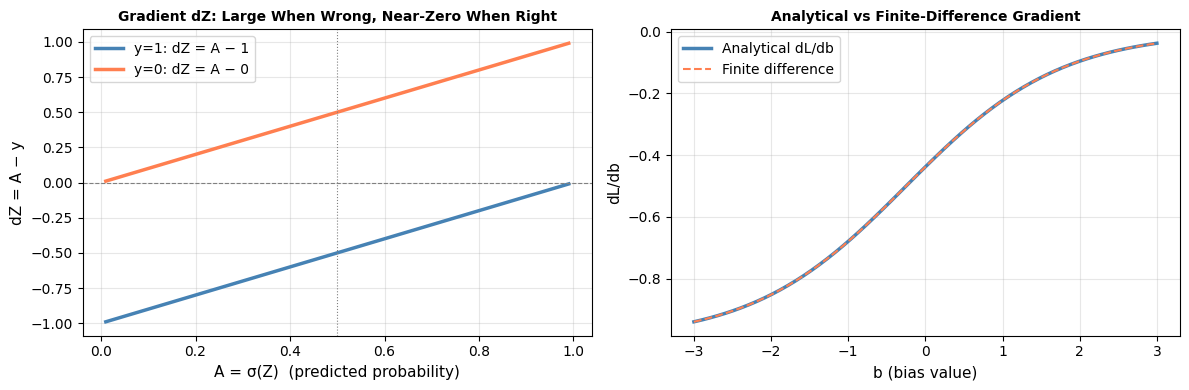

Saved → ../images/04_computation_graph_backprop.png


In [6]:
import os
os.makedirs('../images', exist_ok=True)

# Show how dZ = A-y varies across different (A, y) combinations
A_vals  = np.linspace(0.01, 0.99, 200)
dZ_y1   = A_vals - 1    # y=1
dZ_y0   = A_vals - 0    # y=0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: dZ as function of A for both classes
axes[0].plot(A_vals, dZ_y1, color='steelblue', lw=2.5, label='y=1: dZ = A − 1')
axes[0].plot(A_vals, dZ_y0, color='coral',     lw=2.5, label='y=0: dZ = A − 0')
axes[0].axhline(0, color='grey', lw=0.8, ls='--')
axes[0].axvline(0.5, color='grey', lw=0.8, ls=':')
axes[0].set_xlabel('A = σ(Z)  (predicted probability)', fontsize=11)
axes[0].set_ylabel('dZ = A − y', fontsize=11)
axes[0].set_title('Gradient dZ: Large When Wrong, Near-Zero When Right', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Right: finite difference check across many b values
b_range   = np.linspace(-3, 3, 60)
x_fd      = np.array([[1.0], [0.5]])
w_fd      = np.array([[0.3], [-0.1]])
y_fd      = 1
eps       = 1e-5
analytic  = []
fd_approx = []

for b_val in b_range:
    c = forward_pass(x_fd, w_fd, b_val, y_fd)
    g = backward_pass(c, x_fd, y_fd)
    analytic.append(float(g['db']))
    L_p = forward_pass(x_fd, w_fd, b_val + eps, y_fd)['L']
    L_m = forward_pass(x_fd, w_fd, b_val - eps, y_fd)['L']
    fd_approx.append((L_p - L_m) / (2 * eps))

axes[1].plot(b_range, analytic,  color='steelblue', lw=2.5, label='Analytical dL/db')
axes[1].plot(b_range, fd_approx, color='coral', lw=1.5, ls='--', label='Finite difference')
axes[1].set_xlabel('b (bias value)', fontsize=11)
axes[1].set_ylabel('dL/db', fontsize=11)
axes[1].set_title('Analytical vs Finite-Difference Gradient', fontsize=10, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/04_computation_graph_backprop.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../images/04_computation_graph_backprop.png')

## 6. Revision Corner

---

### One-sentence definition

> Backpropagation is the chain rule applied right-to-left through the computation graph,  
> computing how much each parameter contributed to the loss so that gradient descent can update them.

---

### Why it exists — what problem does it solve?

For a network with millions of parameters, computing each gradient independently would be  
computationally prohibitive. The computation graph ensures each intermediate result is computed  
once in the forward pass and reused in the backward pass. Backprop turns an O(n²) problem  
into an O(n) one.

---

### Interview gotchas

| Question | Common mistake | The reality |
|----------|---------------|-------------|
| **What is dZ in logistic regression?** | Confuse it with dL/dA | dZ = dL/dZ = A − y. This is the result of applying the chain rule through the sigmoid and the cross-entropy together. It simplifies beautifully to A − y. |
| **Why does the forward pass cache Z and A?** | "It doesn't need to" | Backprop needs Z to compute σ'(Z) = A(1−A), and needs A−y directly. Without caching, you'd recompute the entire forward pass at every backward step. |
| **What is the chain rule in one sentence?** | Give the formula without intuition | If output depends on Z which depends on w, then ∂output/∂w = (∂output/∂Z)·(∂Z/∂w). The gradient flows through each operation multiplicatively. |
| **What does finite difference gradient checking do?** | "Verifies the data" | It verifies that your analytically computed gradient matches the numerical approximation [L(θ+ε) − L(θ−ε)]/(2ε). It is a sanity check for your backprop implementation. |
| **What is the shape of dW for nₓ=100?** | Say (1,100) or (100,) | dW has the same shape as W: (nₓ, 1) = (100, 1). Each weight gets its own gradient. |

## 7. Exercises

Write solutions in `exercises/04_computation_graph_and_backprop_exN_label.py`.

---

### ⭐ Exercise 1 — dZ from scratch and verified

Implement `backward_single(A, y, x)` that returns dZ, dW, db for one example.  
Use the formula dZ = A − y, dW = dZ * x, db = dZ.  
Test on four cases: (A=0.9, y=1), (A=0.1, y=1), (A=0.9, y=0), (A=0.1, y=0).  
For each, verify dZ with finite differences on b (ε=1e-5, x=[[1.0],[2.0]], w=[[0.1],[0.2]]).  
All np.isclose checks must print True.

---

### ⭐⭐ Exercise 2 — Full gradient check on W

Use seed 0, nx=4, x=np.random.randn(4,1), w=np.random.randn(4,1), b=0.1, y=1.  
1. Compute the analytical dW using the backward pass formula.
2. For each element w[i], compute the finite-difference estimate of dL/dw[i] using ε=1e-5.
3. Verify all 4 elements match analytically with np.allclose(atol=1e-5).  
Print: analytical dW, finite-diff dW, and the allclose result.

---

### ⭐⭐⭐ Exercise 3 — Build the full logistic regression training loop from scratch

**Scenario:** Deepfake detector proof-of-concept. Input: 4 hand-crafted features per frame.  
Use seed 7. Generate m=50 examples:  
- Deepfake (y=1): X_fake = np.random.randn(4, 25) + 1.5
- Real (y=0):     X_real = np.random.randn(4, 25) − 1.5  
Stack into X (4, 50) and Y (1, 50).

Implement the full training loop for 500 iterations with α=0.3:  
1. Forward: Z = wᵀX + b, A = σ(Z), J = compute_cost(A, Y, m)  
2. Backward: dZ = A − Y, dW = (1/m)·X·dZᵀ, db = (1/m)·np.sum(dZ)  
3. Update: w, b  
Print cost every 100 iterations. After training, print accuracy.  
Plot cost curve and save to `../images/04_computation_graph_exercise.png`.  
Comment: what would happen to the gradients if you forgot the (1/m) factor?